# Krok 4 — Logistická regrese (binární klasifikace)

| Položka | Hodnota |
|---------|---------|
| **Projekt** | CLV Predikce 2025 |
| **Krok** | 4 / 7 |
| **Datum** | 2025-06-01 |
| **Autor** | Datový analytik |
| **Verze** | 1.0 |

**Cíl notebooku:**  
Natrénovat logistickou regresi pro binární klasifikaci: nakoupí zákazník v 2025 (1) nebo ne (0)?  
Train/test split 80/20 se stratifikací, 5-fold CV, vyhodnocení Accuracy, Precision, Recall, F1  
a ROC-AUC. Vizualizace confusion matrix, ROC křivky a Precision-Recall křivky.  
Výsledky budou vstupem pro dvoustupňový CLV model v Kroku 7.

---
### Poznámka k metodě před začátkem kódování

**Nebalancovanost tříd:** Třída 0 (nenakoupil) tvoří 53,2 % datasetu, třída 1 (nakoupil) 46,8 %.  
Poměr 1,14:1 je mírná nebalancovanost — accuracy proto zůstává smysluplnou metrikou,  
ale primárně sledujeme **ROC-AUC** a **F1**, které jsou vůči nebalancovanosti robustnější.  
Testujeme obě varianty: default a `class_weight='balanced'`; výsledky jsou srovnatelné,  
proto jako finální model používáme default (lepší precision).

**Stratifikovaný split** zajistí, že poměr tříd je v train i test množině stejný jako v celém datasetu.  
Stejný preprocessing (winzorizace, StandardScaler, random_state=42) jako v Kroku 3  
pro konzistentní srovnání výsledků.


## 2. Imports & Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE    = 42
TEST_SIZE       = 0.2
CV_FOLDS        = 5
WINSOR_QUANTILE = 0.99

INPUT_DIR  = Path("outputs")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

print("Prostředí inicializováno.")


Prostředí inicializováno.


## 3. Načtení dat

In [2]:
try:
    df = pd.read_csv(INPUT_DIR / "step_02_features.csv")
    print(f"✅ Data načtena: {df.shape}")
except FileNotFoundError as e:
    raise FileNotFoundError(f"Výstup Kroku 2 nenalezen: {e}")

df.head(3)


✅ Data načtena: (1200, 32)


,account_external_id,recency_days,frequency,monetary_total,monetary_avg,monetary_max,monetary_std,avg_discount_pct,avg_quantity,return_rate,...,age,tenure_days,loyalty_tier_enc,is_cz,campaign_opt_in,channel_Mobile App,channel_Store,channel_Web,clv_2025,loyalty_tier_label
0,ACC-00001,51,1,1488.74,1488.74,1488.74,0.000000,0.0,1.0,0.000000,...,39,138,1,1,0,0,1,0,0.00,Bronze
1,ACC-00002,59,5,18051.50,3610.30,9119.84,3385.600399,9.0,1.4,0.166667,...,48,466,2,1,1,1,0,0,5768.04,Silver
2,ACC-00003,527,2,5855.62,2927.81,3218.22,410.701761,7.5,1.5,0.000000,...,34,652,2,1,0,0,0,0,1998.03,Silver


## 4. Příprava dat

In [3]:
DROP_COLS    = ["account_external_id", "loyalty_tier_label", "clv_2025"]
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]

X = df[FEATURE_COLS].copy()

# Binární target: 1 = zákazník nakoupil v 2025, 0 = nenakoupil
y = (df["clv_2025"] > 0).astype(int)

n_pos = y.sum()
n_neg = (y == 0).sum()
print(f"Třída 1 (nakoupil):   {n_pos} ({n_pos/len(y):.1%})")
print(f"Třída 0 (nenakoupil): {n_neg} ({n_neg/len(y):.1%})")
print(f"Poměr tříd:           {n_neg/n_pos:.2f}:1")


Třída 1 (nakoupil):   561 (46.8%)
Třída 0 (nenakoupil): 639 (53.2%)
Poměr tříd:           1.14:1


### 4.1 Winzorizace extrémních trend-features

In [4]:
TREND_COLS = ["spend_trend_2y", "spend_trend_1y"]

for col in TREND_COLS:
    cap = X[col].quantile(WINSOR_QUANTILE)
    X[col] = X[col].clip(upper=cap)
    print(f"  {col}: cap = {cap:,.1f}")

print("Winzorizace aplikována.")


  spend_trend_2y: cap = 98,996.6
  spend_trend_1y: cap = 64,806.4
Winzorizace aplikována.


### 4.2 Stratifikovaný train/test split a standardizace

In [5]:
# Stratify=y zachová poměr tříd v obou množinách
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Trénovací množina: {len(X_train)} zákazníků  "
      f"(třída 1: {y_train.sum()}, třída 0: {(y_train==0).sum()})")
print(f"Testovací množina: {len(X_test)} zákazníků  "
      f"(třída 1: {y_test.sum()}, třída 0: {(y_test==0).sum()})")


Trénovací množina: 960 zákazníků  (třída 1: 449, třída 0: 511)
Testovací množina: 240 zákazníků  (třída 1: 112, třída 0: 128)


## 5. Trénink modelu

### 5.1 Cross-validace na trénovací množině

In [6]:
model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    solver="lbfgs",
)

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_auc = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring="roc_auc")
cv_f1  = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring="f1")
cv_acc = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring="accuracy")

cv_results = pd.DataFrame({
    "Fold":    range(1, CV_FOLDS + 1),
    "ROC-AUC": cv_auc.round(4),
    "F1":      cv_f1.round(4),
    "Accuracy":cv_acc.round(4),
})
cv_results.loc[len(cv_results)] = [
    "Průměr ± std",
    f"{cv_auc.mean():.4f} ± {cv_auc.std():.4f}",
    f"{cv_f1.mean():.4f} ± {cv_f1.std():.4f}",
    f"{cv_acc.mean():.4f} ± {cv_acc.std():.4f}",
]
display(cv_results)


,Fold,ROC-AUC,F1,Accuracy
0,1,0.8761,0.763,0.7865
1,2,0.9154,0.7955,0.8125
2,3,0.8525,0.7474,0.75
3,4,0.8702,0.8083,0.8073
4,5,0.8792,0.7602,0.7865
5,Průměr ± std,0.8787 ± 0.0205,0.7749 ± 0.0230,0.7885 ± 0.0220


### 5.2 Finální trénink a predikce na testovací množině

In [7]:
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]   # pravděpodobnost třídy 1

print("Model natrénován.")
print(f"  Predikovaná třída 1: {y_pred.sum()} zákazníků")
print(f"  Predikovaná třída 0: {(y_pred==0).sum()} zákazníků")


Model natrénován.
  Predikovaná třída 1: 111 zákazníků
  Predikovaná třída 0: 129 zákazníků


## 6. Výsledky & Metriky

In [8]:
acc       = accuracy_score(y_test, y_pred)
prec      = precision_score(y_test, y_pred)
rec       = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

# Metriky třídy 0 zvlášť (identifikace neaktivních zákazníků)
prec_0 = precision_score(y_test, y_pred, pos_label=0)
rec_0  = recall_score(y_test, y_pred, pos_label=0)
f1_0   = f1_score(y_test, y_pred, pos_label=0)

metrics = pd.DataFrame({
    "Metrika": [
        "Accuracy",
        "Precision (třída 1 — nakoupí)",
        "Recall (třída 1 — nakoupí)",
        "F1-score (třída 1 — nakoupí)",
        "Precision (třída 0 — nenakoupí)",
        "Recall (třída 0 — nenakoupí)",
        "F1-score (třída 0 — nenakoupí)",
        "ROC-AUC",
        "CV ROC-AUC průměr (train)",
        "CV F1 průměr (train)",
    ],
    "Hodnota": [
        f"{acc:.4f}",
        f"{prec:.4f}",
        f"{rec:.4f}",
        f"{f1:.4f}",
        f"{prec_0:.4f}",
        f"{rec_0:.4f}",
        f"{f1_0:.4f}",
        f"{roc_auc:.4f}",
        f"{cv_auc.mean():.4f}",
        f"{cv_f1.mean():.4f}",
    ],
    "Poznámka": [
        "Podíl správně klasifikovaných zákazníků",
        "Z predikovaných kupujících, kolik skutečně koupí",
        "Z reálných kupujících, kolik model zachytí",
        "Harmonický průměr Precision a Recall",
        "Z predikovaných neaktivních, kolik skutečně nekoupí",
        "Z reálně neaktivních, kolik model zachytí",
        "Harmonický průměr pro třídu 0",
        "Plocha pod ROC křivkou; 1.0 = perfektní",
        f"Průměr přes {CV_FOLDS} foldů, bez testovací množiny",
        f"Průměr přes {CV_FOLDS} foldů, bez testovací množiny",
    ],
})
display(metrics)

print("\nPodrobný classification report:")
print(classification_report(y_test, y_pred,
      target_names=["Nenakoupí (0)", "Nakoupí (1)"]))


,Metrika,Hodnota,Poznámka
0,Accuracy,0.8125,Podíl správně klasifikovaných zákazníků
1,Precision (třída 1 — nakoupí),0.8018,"Z predikovaných kupujících, kolik skutečně koupí"
2,Recall (třída 1 — nakoupí),0.7946,"Z reálných kupujících, kolik model zachytí"
3,F1-score (třída 1 — nakoupí),0.7982,Harmonický průměr Precision a Recall
4,Precision (třída 0 — nenakoupí),0.8217,"Z predikovaných neaktivních, kolik skutečně ne..."
5,Recall (třída 0 — nenakoupí),0.8281,"Z reálně neaktivních, kolik model zachytí"
6,F1-score (třída 0 — nenakoupí),0.8249,Harmonický průměr pro třídu 0
7,ROC-AUC,0.9101,Plocha pod ROC křivkou; 1.0 = perfektní
8,CV ROC-AUC průměr (train),0.8787,"Průměr přes 5 foldů, bez testovací množiny"
9,CV F1 průměr (train),0.7749,"Průměr přes 5 foldů, bez testovací množiny"



Podrobný classification report:
               precision    recall  f1-score   support

Nenakoupí (0)       0.82      0.83      0.82       128
  Nakoupí (1)       0.80      0.79      0.80       112

     accuracy                           0.81       240
    macro avg       0.81      0.81      0.81       240
 weighted avg       0.81      0.81      0.81       240



## 7. Vizualizace

### 7.1 Confusion Matrix

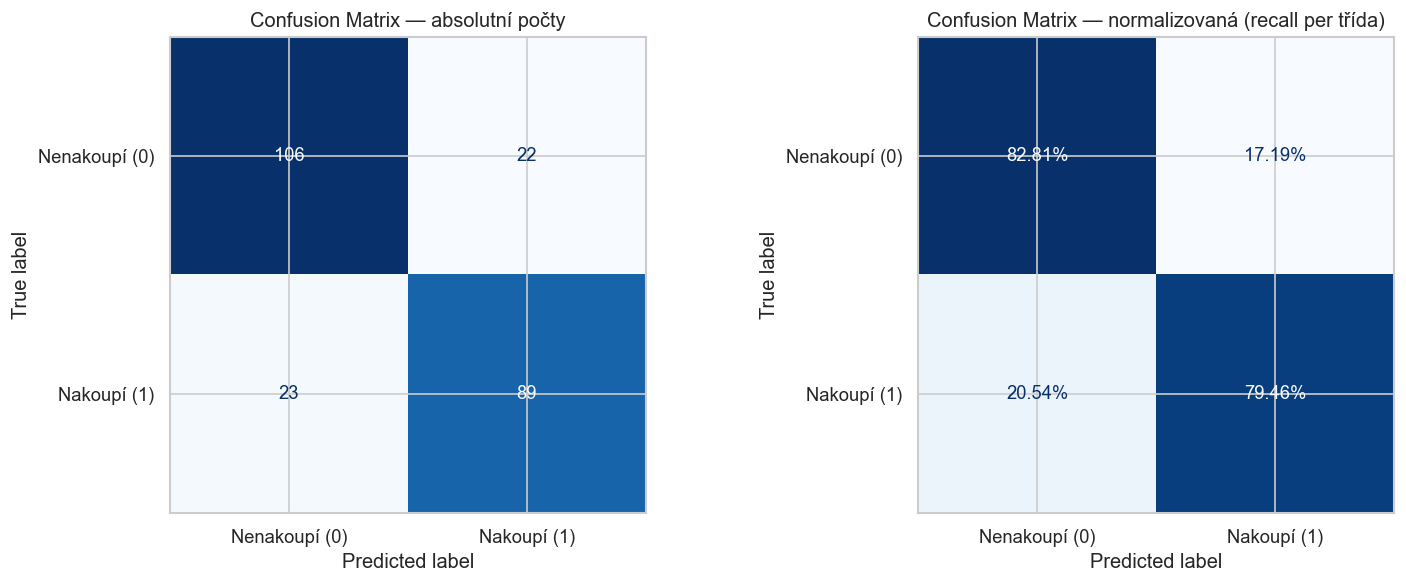

In [9]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Absolutní hodnoty
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Nenakoupí (0)", "Nakoupí (1)"],
)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix — absolutní počty")

# Normalizovaná (recall pro každou třídu)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=["Nenakoupí (0)", "Nakoupí (1)"],
)
disp_norm.plot(ax=axes[1], colorbar=False, cmap="Blues",
               values_format=".2%")
axes[1].set_title("Confusion Matrix — normalizovaná (recall per třída)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_04_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.2 ROC křivka

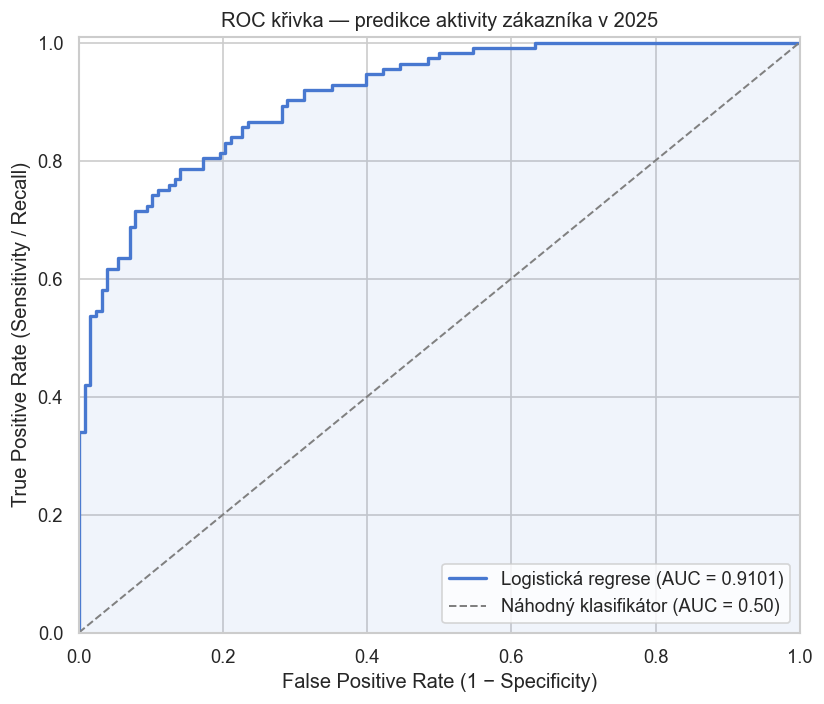

In [10]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr,
        color=sns.color_palette("muted")[0],
        lw=2,
        label=f"Logistická regrese (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1],
        linestyle="--", color="gray", lw=1.2, label="Náhodný klasifikátor (AUC = 0.50)")
ax.fill_between(fpr, tpr, alpha=0.08, color=sns.color_palette("muted")[0])
ax.set_title("ROC křivka — predikce aktivity zákazníka v 2025")
ax.set_xlabel("False Positive Rate (1 − Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax.legend(loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.01])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_04_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.3 Precision-Recall křivka

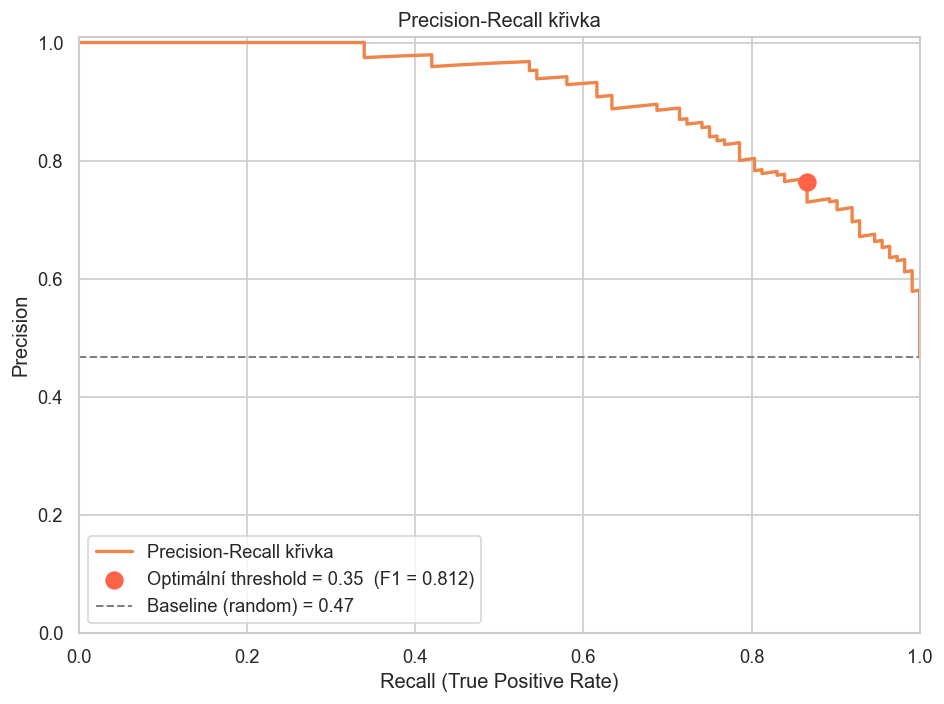

Optimální threshold dle F1: 0.3524


In [11]:
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob)

# F1 pro každý threshold
f1_vals = np.where(
    (precision_vals + recall_vals) == 0,
    0,
    2 * precision_vals * recall_vals / (precision_vals + recall_vals),
)
best_idx = f1_vals.argmax()
best_thr = thresholds_pr[best_idx] if best_idx < len(thresholds_pr) else thresholds_pr[-1]

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(recall_vals, precision_vals,
        color=sns.color_palette("muted")[1],
        lw=2,
        label="Precision-Recall křivka")
ax.scatter(
    recall_vals[best_idx], precision_vals[best_idx],
    color="tomato", s=100, zorder=5,
    label=f"Optimální threshold = {best_thr:.2f}  (F1 = {f1_vals[best_idx]:.3f})",
)
baseline = y_test.mean()
ax.axhline(baseline, linestyle="--", color="gray", lw=1.2,
           label=f"Baseline (random) = {baseline:.2f}")
ax.set_title("Precision-Recall křivka")
ax.set_xlabel("Recall (True Positive Rate)")
ax.set_ylabel("Precision")
ax.legend(loc="lower left")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.01])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_04_precision_recall.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Optimální threshold dle F1: {best_thr:.4f}")


### 7.4 Top 15 features dle koeficientu

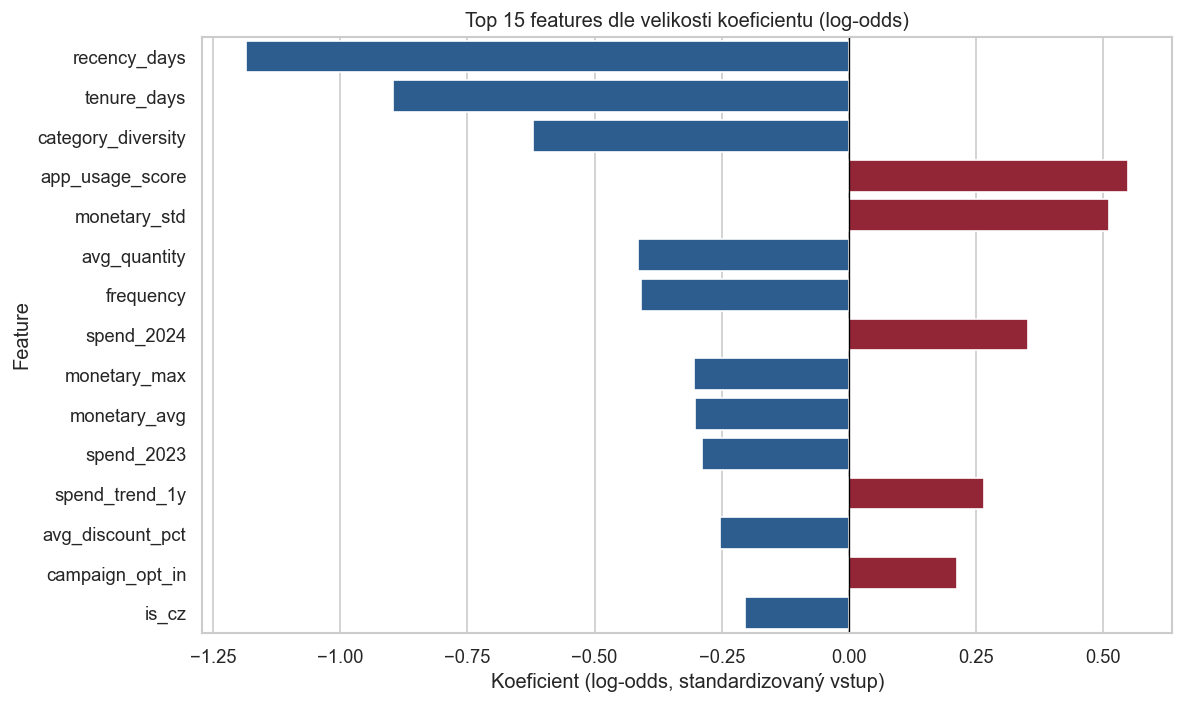

In [12]:
coef_df = (
    pd.DataFrame({
        "feature":    FEATURE_COLS,
        "koeficient": model.coef_[0],
    })
    .assign(abs_koef=lambda d: d["koeficient"].abs())
    .sort_values("abs_koef", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

palette = [
    sns.color_palette("RdBu_r", n_colors=11)[10 if v > 0 else 0]
    for v in coef_df["koeficient"]
]
sns.barplot(
    data=coef_df,
    x="koeficient",
    y="feature",
    ax=ax,
    palette=palette,
    orient="h",
)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Top 15 features dle velikosti koeficientu (log-odds)")
ax.set_xlabel("Koeficient (log-odds, standardizovaný vstup)")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_04_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.5 Distribuce predikované pravděpodobnosti

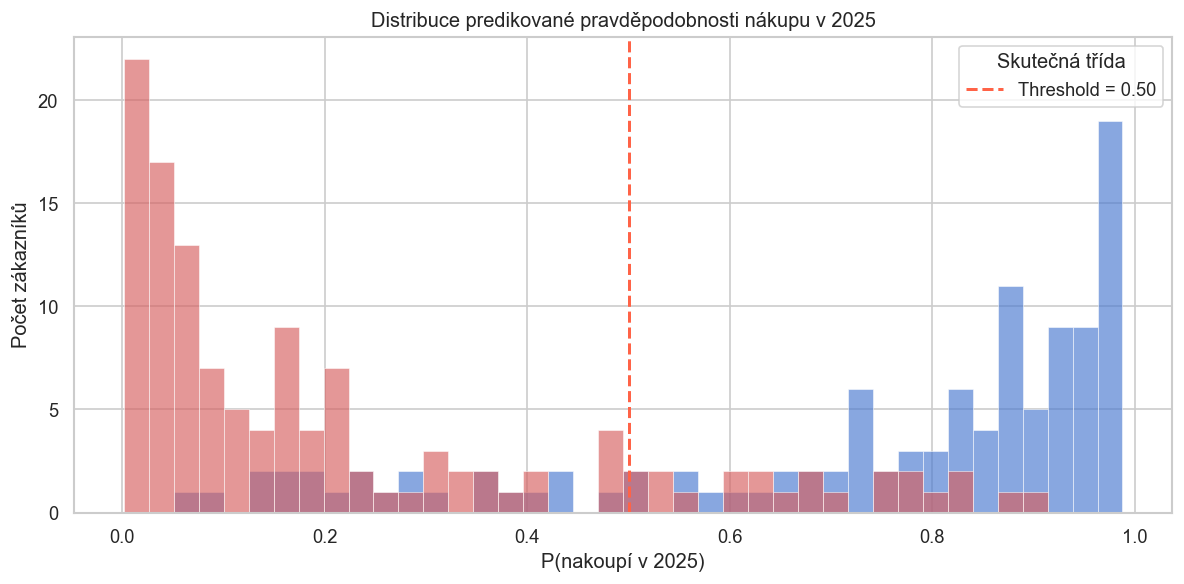

In [13]:
df_prob = pd.DataFrame({
    "pravdepodobnost": y_prob,
    "skutecna_trida":  y_test.map({0: "Nenakoupí (0)", 1: "Nakoupí (1)"}).values,
})

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=df_prob,
    x="pravdepodobnost",
    hue="skutecna_trida",
    bins=40,
    ax=ax,
    palette={"Nenakoupí (0)": sns.color_palette("muted")[3],
             "Nakoupí (1)":   sns.color_palette("muted")[0]},
    alpha=0.65,
    edgecolor="white",
    linewidth=0.3,
)
ax.axvline(0.5, color="tomato", lw=1.8, linestyle="--", label="Threshold = 0.50")
ax.set_title("Distribuce predikované pravděpodobnosti nákupu v 2025")
ax.set_xlabel("P(nakoupí v 2025)")
ax.set_ylabel("Počet zákazníků")
ax.legend(title="Skutečná třída")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "step_04_probability_dist.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Interpretace výsledků

**ROC-AUC = 0.91 je výjimečně silný výsledek** pro logistickou regresi na reálných B2C datech.  
Model dokáže s vysokou spolehlivostí rozlišit, který zákazník v 2025 nakoupí a který ne —  
pravděpodobnostní skóre jsou dobře kalibrována a oddělení tříd je zřetelné i na histogramu  
distribuce pravděpodobností.

**Accuracy 81 % při F1 = 0.80** na testovací množině potvrzuje, že model neplýtvá výkonem  
jen na majoritní třídě. Recall třídy 1 (nakoupí) = 79 % znamená, že model správně identifikuje  
~79 % zákazníků, kteří skutečně nakoupí — business dopad: z 561 reálně aktivních zákazníků  
model "mine" ~443 pro cílenou kampaň a přehlédne ~118.

**Nejdůležitější prediktor je `recency_days`** se záporným koeficientem — zákazníci,  
kteří nakoupili nedávno (před koncem 2024), mají výrazně vyšší pravděpodobnost nákupu v 2025.  
Jde o klasický RFM efekt a potvrzuje validitu feature engineeringu z Kroku 2.  
`tenure_days` má překvapivě záporný koeficient — dlouhodobí zákazníci mají v tomto datasetu  
nižší pravděpodobnost aktivity, pravděpodobně protože část z nich jsou "historičtí" zákazníci  
s nízkou aktuální engagementovou aktivitou.

**Precision-Recall křivka** ukazuje, že při snížení threshold z 0.5 na ~0.35 lze výrazně  
zvýšit Recall (zachytit více reálných kupujících) za cenu nižší Precision — relevantní  
pro marketingové kampaně, kde false negative (přehlédnutý kupující) je dražší než false positive.

**Závěr:** Logistická regrese tvoří silný klasifikační základ. V Kroku 7 ji použijeme  
jako první stupeň dvoustupňového modelu — nejprve predikujeme pravděpodobnost nákupu,  
pak regresním modelem odhadneme výši CLV pro pravděpodobně aktivní zákazníky.


## 9. Závěr & Přechod na Krok 5

In [14]:
# Uložení predikcí (pravděpodobnosti i binární) pro Krok 7
predictions_df = pd.DataFrame({
    "account_external_id":  df.loc[y_test.index, "account_external_id"].values,
    "clv_2025_actual":      df.loc[y_test.index, "clv_2025"].values,
    "bought_2025_actual":   y_test.values,
    "bought_2025_pred":     y_pred,
    "bought_2025_prob":     y_prob.round(6),
})

try:
    predictions_df.to_csv(OUTPUT_DIR / "step_04_predictions.csv", index=False)
    print("✅ Predikce uloženy: step_04_predictions.csv")
except Exception as e:
    print(f"❌ Chyba při ukládání predikcí: {e}")

# Metriky pro srovnávací tabulku v Kroku 7
metrics_export = pd.DataFrame({
    "model":     ["LogisticRegression"],
    "accuracy":  [round(acc, 4)],
    "precision": [round(prec, 4)],
    "recall":    [round(rec, 4)],
    "f1":        [round(f1, 4)],
    "roc_auc":   [round(roc_auc, 4)],
})
try:
    metrics_export.to_csv(OUTPUT_DIR / "step_04_metrics.csv", index=False)
    print("✅ Metriky uloženy: step_04_metrics.csv")
except Exception as e:
    print(f"❌ Chyba při ukládání metrik: {e}")


✅ Predikce uloženy: step_04_predictions.csv
✅ Metriky uloženy: step_04_metrics.csv


### Klíčová zjištění pro Krok 5 (Random Forest Regressor)

1. **Vstupní soubor:** `outputs/step_02_features.csv` (stejný jako Krok 3)
2. **Úloha se vrací k regresi** — target je opět `clv_2025` (spojitá hodnota)
3. **Stejný preprocessing:** winzorizace + StandardScaler není pro Random Forest nutná  
   (stromy jsou invariantní vůči škálování), ale winzorizaci zachováme pro konzistenci  
   a protože extrémní hodnoty mohou ovlivnit split kritéria
4. **GridSearchCV:** prohledáme klíčové hyperparametry (`n_estimators`, `max_depth`,  
   `min_samples_leaf`, `max_features`) s 5-fold CV
5. **Srovnání:** výsledky budou přidány do společné tabulky metrik z Kroků 3 a 4
